# Работа с Pandas Series

## 1. Создание Series из списка

Создайте Series из списка чисел [5, 15, 25, 35, 45] 
с индексами ['a', 'b', 'c', 'd', 'e'].

Выведите его на экран и определите его тип данных.

---

In [1]:
import pandas as pd


values = [5, 15, 25, 35, 45]
indices = ["a", "b", "c", "d", "e"]

series = pd.Series(values, index=indices)

print(series)
print(type(series))
print(series.dtype)

a     5
b    15
c    25
d    35
e    45
dtype: int64
<class 'pandas.core.series.Series'>
int64


## 2. Получение элемента Series

Дан Series с индексами ['A', 'B', 'C', 'D', 'E'] 
и значениями [12, 24, 36, 48, 60].

Используйте:
- .loc[] для получения элемента с индексом 'C';
- .iloc[] для получения третьего элемента.

---

In [2]:
indices = ["A", "B", "C", "D", "E"]
values = [12, 24, 36, 48, 60]

series = pd.Series(values, index=indices)

element_loc = series.loc["C"]
element_iloc = series.iloc[2]

print("Элемент с индексом 'C' (.loc):", element_loc)
print("Третий элемент (.iloc):", element_iloc)

Элемент с индексом 'C' (.loc): 36
Третий элемент (.iloc): 36


## 3. Фильтрация данных с помощью логической индексации

Создайте Series из массива NumPy:

np.array([4, 9, 16, 25, 36, 49, 64]).

Выберите только те элементы, которые больше 20,
и выведите результат.

---

In [6]:
import numpy as np

array = np.array([4, 9, 16, 25, 36, 49, 64])
series = pd.Series(array)

filtered_series = series[series > 20]

print(filtered_series)

3    25
4    36
5    49
6    64
dtype: int32


## 4. Просмотр первых и последних элементов

Создайте Series, содержащий 50 случайных целых чисел от 1 до 100 
(используйте np.random.randint).

Выведите первые 7 и последние 5 элементов с помощью 
методов .head() и .tail().

---

In [8]:
np.random.seed(42)
data = np.random.randint(1, 101, 50)

series = pd.Series(data)

print("Первые 7 элементов:")
print(series.head(7))

print("\nПоследние 5 элементов:")
print(series.tail(5))

Первые 7 элементов:
0    52
1    93
2    15
3    72
4    61
5    21
6    83
dtype: int32

Последние 5 элементов:
45    51
46     7
47    21
48    73
49    39
dtype: int32


## 5. Определение типа данных Series

Создайте Series из списка:

['cat', 'dog', 'rabbit', 'parrot', 'fish'].

Определите тип данных с помощью .dtype, 
затем преобразуйте его в category с помощью .astype().

---

In [9]:
animals = ["cat", "dog", "rabbit", "parrot", "fish"]

series = pd.Series(animals)

print("Исходный тип данных:", series.dtype)

series = series.astype("category")

print("Тип данных после преобразования:", series.dtype)

Исходный тип данных: object
Тип данных после преобразования: category


## 6. Проверка пропущенных значений

Создайте Series с данными:

[1.2, np.nan, 3.4, np.nan, 5.6, 6.8].

Напишите код, который проверяет, есть ли в Series 
пропущенные значения (NaN), и выведите индексы таких элементов.

---

In [10]:
data = [1.2, np.nan, 3.4, np.nan, 5.6, 6.8]

series = pd.Series(data)

has_nan = series.isna().any()
nan_indices = series[series.isna()].index

print("Есть ли пропущенные значения:", has_nan)
print("Индексы пропущенных значений:", list(nan_indices))

Есть ли пропущенные значения: True
Индексы пропущенных значений: [1, 3]


## 7. Заполнение пропущенных значений

Используйте Series из предыдущего задания и замените все NaN 
на среднее значение всех непустых элементов. Выведите результат.

---

In [11]:
data = [1.2, np.nan, 3.4, np.nan, 5.6, 6.8]
series = pd.Series(data)

mean_value = series.mean()

filled_series = series.fillna(mean_value)

print("Среднее значение:", mean_value)
print("Series после заполнения NaN:")
print(filled_series)

Среднее значение: 4.25
Series после заполнения NaN:
0    1.20
1    4.25
2    3.40
3    4.25
4    5.60
5    6.80
dtype: float64


## 8. Арифметические операции с Series

Создайте два Series:

s1 = pd.Series([10, 20, 30, 40], index=['a', 'b', 'c', 'd'])

s2 = pd.Series([5, 15, 25, 35], index=['b', 'c', 'd', 'e'])

Выполните сложение s1 + s2.  
Объясните, почему в результате появляются NaN, 
и замените их на 0.

---

In [12]:
s1 = pd.Series([10, 20, 30, 40], index=["a", "b", "c", "d"])
s2 = pd.Series([5, 15, 25, 35], index=["b", "c", "d", "e"])

result = s1 + s2

print("Результат сложения:")
print(result)

# Замена NaN на 0
result_filled = result.fillna(0)

print("\nПосле замены NaN на 0:")
print(result_filled)

Результат сложения:
a     NaN
b    25.0
c    45.0
d    65.0
e     NaN
dtype: float64

После замены NaN на 0:
a     0.0
b    25.0
c    45.0
d    65.0
e     0.0
dtype: float64


## 9. Применение функции к Series

Создайте Series из чисел [2, 4, 6, 8, 10].  
Напишите код, который применяет к каждому элементу функцию 
вычисления квадратного корня с помощью .apply(np.sqrt).

In [13]:
numbers = pd.Series([2, 4, 6, 8, 10])

sqrt_series = numbers.apply(np.sqrt)

print("Исходный Series:")
print(numbers)

print("\nПосле применения sqrt:")
print(sqrt_series)

Исходный Series:
0     2
1     4
2     6
3     8
4    10
dtype: int64

После применения sqrt:
0    1.414214
1    2.000000
2    2.449490
3    2.828427
4    3.162278
dtype: float64


## 10. Основные статистические методы

Создайте Series из 20 случайных чисел от 50 до 150 
(используйте np.random.randint).

Найдите:
- сумму,
- среднее,
- минимальное значение,
- максимальное значение,
- стандартное отклонение.

---

In [14]:
np.random.seed(42)
data = np.random.randint(50, 151, 20)

series = pd.Series(data)

print("Series:")
print(series)

print("\nСумма:", series.sum())
print("Среднее:", series.mean())
print("Минимум:", series.min())
print("Максимум:", series.max())
print("Стандартное отклонение:", series.std())

Series:
0     101
1     142
2      64
3     121
4     110
5      70
6     132
7     136
8     124
9     124
10    137
11    149
12     73
13     52
14     71
15    102
16     51
17    137
18     79
19     87
dtype: int32

Сумма: 2062
Среднее: 103.1
Минимум: 51
Максимум: 149
Стандартное отклонение: 32.28964311712935


## 11. Работа с временными рядами

Создайте Series, где индексами будут даты с 1 по 10 марта 2024 года:

pd.date_range(start='2024-03-01', periods=10, freq='D')

Значения — случайные числа от 10 до 100.

Выберите данные за период с 5 по 8 марта.

---

In [15]:
np.random.seed(42)

dates = pd.date_range(start="2024-03-01", periods=10, freq="D")
values = np.random.randint(10, 101, 10)

series = pd.Series(values, index=dates)

print("Весь временной ряд:")
print(series)

filtered = series["2024-03-05":"2024-03-08"]

print("\nДанные с 5 по 8 марта:")
print(filtered)

Весь временной ряд:
2024-03-01    61
2024-03-02    24
2024-03-03    81
2024-03-04    70
2024-03-05    30
2024-03-06    92
2024-03-07    96
2024-03-08    84
2024-03-09    84
2024-03-10    97
Freq: D, dtype: int32

Данные с 5 по 8 марта:
2024-03-05    30
2024-03-06    92
2024-03-07    96
2024-03-08    84
Freq: D, dtype: int32


## 12. Проверка уникальности индексов

Создайте Series с индексами:

['A', 'B', 'A', 'C', 'D', 'B']

и значениями:

[10, 20, 30, 40, 50, 60]

Проверьте, являются ли индексы уникальными.

Если нет, сгруппируйте повторяющиеся индексы 
и сложите их значения.

---

In [16]:
indices = ["A", "B", "A", "C", "D", "B"]
values = [10, 20, 30, 40, 50, 60]

series = pd.Series(values, index=indices)

print("Series:")
print(series)

print("\nИндексы уникальны?:", series.index.is_unique)

if not series.index.is_unique:
    grouped = series.groupby(level=0).sum()
    print("\nПосле группировки и суммирования:")
    print(grouped)

Series:
A    10
B    20
A    30
C    40
D    50
B    60
dtype: int64

Индексы уникальны?: False

После группировки и суммирования:
A    40
B    80
C    40
D    50
dtype: int64


## 13. Преобразование строковых дат в DatetimeIndex

Создайте Series, где индексами будут строки:

['2024-03-10', '2024-03-11', '2024-03-12'],

а значениями:

[100, 200, 300].

Преобразуйте индексы в DatetimeIndex 
и выведите тип данных индекса.

---

In [17]:
dates = ["2024-03-10", "2024-03-11", "2024-03-12"]
values = [100, 200, 300]

series = pd.Series(values, index=dates)

print("До преобразования:")
print(series)
print("Тип индекса:", type(series.index))

# Преобразование индекса
series.index = pd.to_datetime(series.index)

print("\nПосле преобразования:")
print(series)
print("Тип индекса:", type(series.index))

До преобразования:
2024-03-10    100
2024-03-11    200
2024-03-12    300
dtype: int64
Тип индекса: <class 'pandas.core.indexes.base.Index'>

После преобразования:
2024-03-10    100
2024-03-11    200
2024-03-12    300
dtype: int64
Тип индекса: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>


## 14. Чтение данных из CSV-файла

Создайте CSV-файл data.csv со следующими данными:

Дата,Цена
2024-03-01,100
2024-03-02,110
2024-03-03,105
2024-03-04,120
2024-03-05,115

Считайте файл с помощью pandas и выведите полученный DataFrame.

In [18]:
data = {
    "Дата": [
        "2024-03-01",
        "2024-03-02",
        "2024-03-03",
        "2024-03-04",
        "2024-03-05"
    ],
    "Цена": [100, 110, 105, 120, 115]
}

df = pd.DataFrame(data)

df.to_csv("data.csv", index=False)

print("Файл data.csv создан.")

Файл data.csv создан.


In [19]:
df = pd.read_csv("data.csv")

print("Считанный DataFrame:")
print(df)

Считанный DataFrame:
         Дата  Цена
0  2024-03-01   100
1  2024-03-02   110
2  2024-03-03   105
3  2024-03-04   120
4  2024-03-05   115


## 15. Построение графика на основе Series

Создайте Series, где индексами будут даты 
с 1 по 30 марта 2024 года, 
а значениями — случайные числа от 50 до 150.

Постройте график значений с помощью matplotlib.

Добавьте:
- заголовок,
- подписи осей,
- сетку.
---

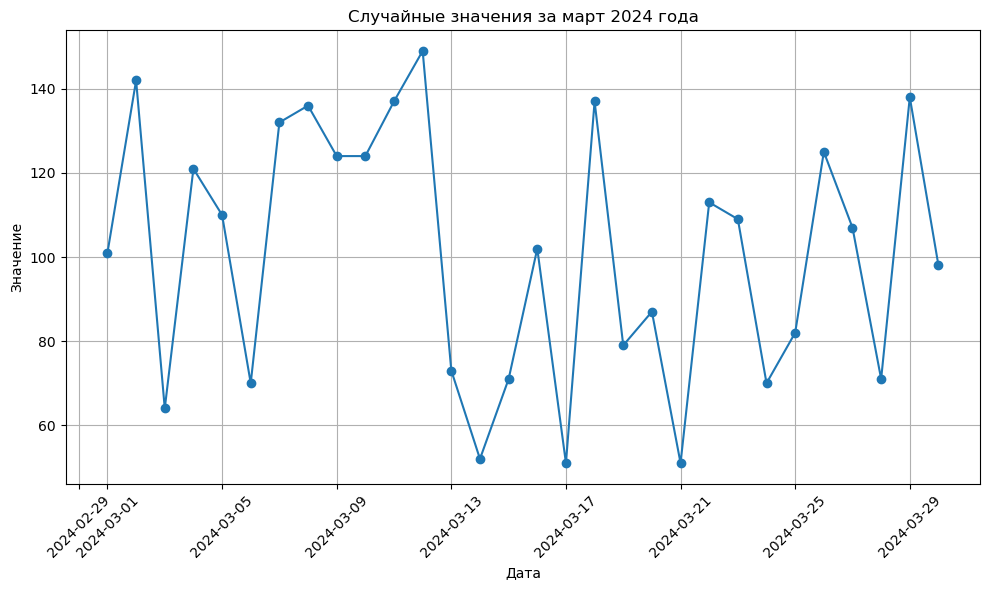

In [20]:
import matplotlib.pyplot as plt
%matplotlib inline


# Фиксация генератора случайных чисел
np.random.seed(42)

# Создание дат
dates = pd.date_range(start="2024-03-01", end="2024-03-30", freq="D")

# Генерация случайных значений
values = np.random.randint(50, 151, len(dates))

# Создание Series
series = pd.Series(values, index=dates)

# Построение графика
plt.figure(figsize=(10, 6))

plt.plot(series.index, series.values, marker="o")

plt.title("Случайные значения за март 2024 года")
plt.xlabel("Дата")
plt.ylabel("Значение")
plt.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# Индивидуальное задание
## 1. Сравнение температуры в двух городах

Создайте Series, где индексами будут даты 
с 1 по 10 марта 2024 года, 
а значениями — температуры в двух городах.

Постройте графики изменения температуры на одном графике.

Добавьте:
- легенду,
- выделите день с наибольшей разницей температур между городами.

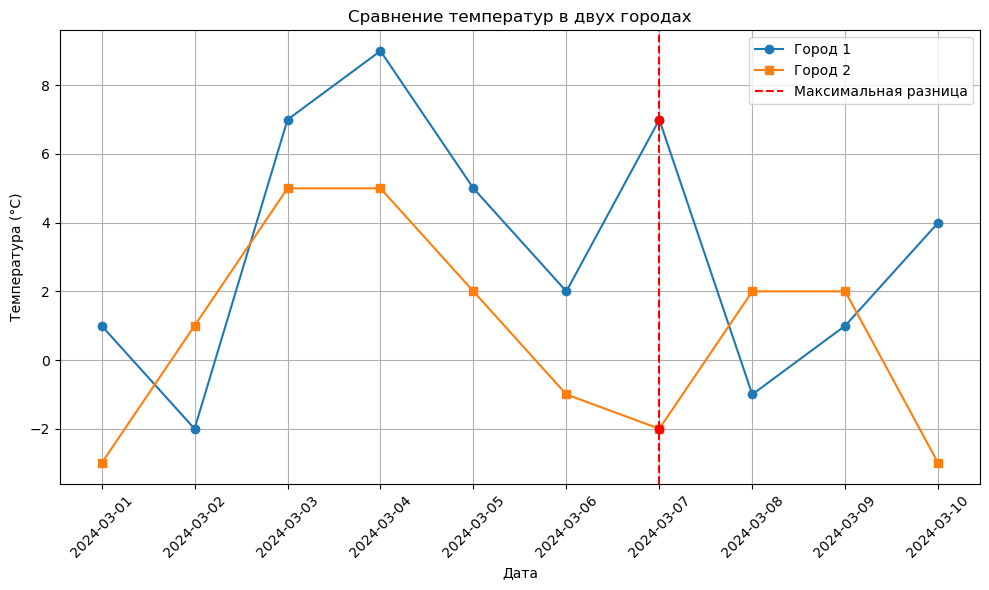

Дата с наибольшей разницей: 2024-03-07
Максимальная разница температур: 9


In [21]:
# Фиксация генератора случайных чисел
np.random.seed(42)

# Создание дат
dates = pd.date_range(start="2024-03-01", end="2024-03-10", freq="D")

# Генерация температур
temp_city1 = np.random.randint(-5, 10, len(dates))
temp_city2 = np.random.randint(-5, 10, len(dates))

# Создание Series
city1 = pd.Series(temp_city1, index=dates)
city2 = pd.Series(temp_city2, index=dates)

# Вычисление разницы температур
difference = (city1 - city2).abs()

max_diff_date = difference.idxmax()
max_diff_value = difference.max()

# Построение графика
plt.figure(figsize=(10, 6))

plt.plot(city1.index, city1.values, marker="o", label="Город 1")
plt.plot(city2.index, city2.values, marker="s", label="Город 2")

# Выделение дня с максимальной разницей
plt.axvline(max_diff_date, color="red", linestyle="--",
            label="Максимальная разница")

plt.scatter(
    max_diff_date,
    city1[max_diff_date],
    color="red",
    zorder=5
)

plt.scatter(
    max_diff_date,
    city2[max_diff_date],
    color="red",
    zorder=5
)

plt.title("Сравнение температур в двух городах")
plt.xlabel("Дата")
plt.ylabel("Температура (°C)")
plt.legend()
plt.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

print("Дата с наибольшей разницей:", max_diff_date.date())
print("Максимальная разница температур:", max_diff_value)